## Evaluating Cross-Regional and Demographic Yield Disparities with KMeans

#### Summary
Standard university enrollment models heavily rely on raw application volumes, frequently covering up underlying behavioral risks and demographic imbalances. This project deploys an unsupervised learning framework ($K$-Means clustering) to uncover hidden behavioral pipelines across **1,400+** high schools interacting with University of California, Los Angeles (*UCLA*) admissions. By executing a cross-regional comparative analysis separating in-state (*California*) and out-of-state (*Non-California*) institutional pipelines, this model successfully maps localized strategic strongholds against systemic conversion risks.

Our analysis uncovered two primary structural insights:
* **The Out-of-State "Ghosting" Phenomenon:** While in-state markets demonstrate massive, highly competitive members, UCLA's out-of-state market is highly fragmented. The algorithm successfully isolated a massive institutional liability zone (**Cluster 1**) characterized by a stable **17.14%** acceptance rate but an absolute **0.00% enrollment yield**. This exposes high-performing out-of-state schools where applicants reject a tier-1 University for a university potentially more fit for them.
* **Demographic Anchoring:** Cross-regional recruitment success is heavily layered by gender. In the non-California market, UCLA’s only highly functional pipeline (**Cluster 0**) converts at a massive **54.94%** total yield, but is overwhelmingly anchored by female conversion tracks (**19.88%** female yield vs. **11.35%** male yield).

**Strategic Paradigm Shift:** Rather than continuing inefficient, blanket out-of-state recruitment expenditures, this framework provides a data-validated blueprint for UCLA's enrollment management. The university should immediately freeze physical recruitment travel to **Cluster 1**  pipelines and aggressively reallocate marketing capital to protect and scale the high-converting, female-driven anchor markets in **Cluster 0**.

#### Imports
For this project we will need the following:
- `numpy`: Used for matrices and running operations on data.
- `matplotlib`: Used for visualize data
- `pandas`: Handling data
- `os` and `sys`: Setting up the path

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys

sys.path.append(os.path.abspath('..'))

np.random.seed(47)

### 1. Data Ingestion and Source Provenance

To evaluate institutional and demographic yield dynamics, our pipeline ingests raw, high-fidelity admissions records sourced directly from the [University of California Information Center](https://www.universityofcalifornia.edu/about-us/information-center/admissions-source-school). The underlying dataset aggregates school-level metrics detailing application volume, admission rates, and enrollment yields grouping by demographic cohorts. 

Due to the structural formatting of the institutional export, the ingestion pipeline uses a tab-separated delimiter (`\t`) utilizing a UTF-16 encoding layer to preserve structural integrity and prevent artifacts during dataframe initialization.

In [2]:
df = pd.read_csv('../data/GENDER_CALI_HS.csv', delimiter='\t', encoding='utf-16')

df.head()

,Calculation1,School,City,County/State/Country,Count,All,Female,Male,Other,Unknown
0,21ST CENTURY LEARNING INST54886,21ST CENTURY LEARNING INST,Beaumont,Riverside,App,NaN,NaN,NaN,NaN,NaN
1,21ST CENTURY LEARNING INST54886,21ST CENTURY LEARNING INST,Beaumont,Riverside,Adm,NaN,NaN,NaN,NaN,NaN
2,21ST CENTURY LEARNING INST54886,21ST CENTURY LEARNING INST,Beaumont,Riverside,Enr,NaN,NaN,NaN,NaN,NaN
3,32ND USC PERFORMING ARTS SCHOOL59062,32ND USC PERFORMING ARTS SCHOOL,Los Angeles,Los Angeles,App,NaN,NaN,NaN,NaN,NaN
4,32ND USC PERFORMING ARTS SCHOOL59062,32ND USC PERFORMING ARTS SCHOOL,Los Angeles,Los Angeles,Adm,NaN,NaN,NaN,NaN,NaN


Here we import our data cleaning utility:

In [3]:
import src.data_pipeline as dp

### 2. Custom Pipeline Execution: Cleaning, Restructuring, and Feature Engineering

With the raw data ingested, we route the data through a series of preprocessing functions from our custom data pipeline package (`dp`). This modular orchestration cleans structural noise, computes features, and cleans up NaN values:

* **`clean_data`**: Handles structural formatting anomalies, drops systemic null values, and enforces strict datatype integrity across all incoming columns.
* **`create_parseable_df`**: Restructures the raw tabular layout into a flat, highly queryable dataframe ready for algorithmic ingestion.
* **`compute_funnels`**: Executes feature engineering to generate the percentage-based conversion metrics (Acceptance and Yield rates) across all major institutional and demographic cohorts.

In [4]:
df = dp.clean_data(df)
df = dp.create_parseable_df(df)
df = dp.compute_funnels(df)

df.head()

,School,City,County/State/Country,App_All,App_Female,App_Male,App_Other,App_Unknown,Adm_All,Adm_Female,...,Acceptance_All,Yield_All,Acceptance_Male,Yield_Male,Acceptance_Other,Yield_Other,Acceptance_Unknown,Yield_Unknown,Acceptance_Female,Yield_Female
1120,WASHINGTON HIGH SCHOOL,Fremont,Alameda,139.0,67.0,67.0,0.0,0.0,14.0,5.0,...,0.100719,0.428571,0.134328,0.333333,0.0,0.0,0.0,0.0,0.074627,0.6
546,MADISON PARK ACADEMY,Oakland,Alameda,14.0,7.0,6.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
314,SAN LORENZO HIGH SCHOOL,San Lorenzo,Alameda,21.0,15.0,6.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1151,OAKLAND MILITARY INST COL PREP,Oakland,Alameda,14.0,9.0,5.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
731,ALBANY HIGH SCHOOL,Albany,Alameda,154.0,68.0,79.0,0.0,0.0,12.0,5.0,...,0.077922,0.500000,0.088608,0.428571,0.0,0.0,0.0,0.0,0.073529,0.6


### 3. Feature Matrix Isolation and Array Conversions

To transition our structured dataset from an DataFrame into an object suitable for numerical computation, we isolate the continuous numerical variables. By slicing the dataframe from the third index forward, we strip out descriptive institutional metadata (such as school names) and extract the pure behavioral funnel metrics and admission values.

This slice is converted into a NumPy array ($X$).

In [5]:
X = df[df.columns[3:]].to_numpy()
X, X.shape

(array([[1.39000000e+02, 6.70000000e+01, 6.70000000e+01, ...,
         0.00000000e+00, 7.46268657e-02, 6.00000000e-01],
        [1.40000000e+01, 7.00000000e+00, 6.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.10000000e+01, 1.50000000e+01, 6.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [7.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [9.00000000e+00, 6.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]),
 (1206, 25))

Here we import our necessary models such as:
- `StandardScaler`: Normalizes our data
- `KMeans`: Allows us to cluster our data to find relationships.

In [6]:
import src.models as models

### 4. Continuous Feature Normalization via StandardScaler

Unsupervised learning algorithms like $K$-Means rely strictly on Euclidean distance metrics ($d = \sqrt{\sum (p_i - q_i)^2}$) to establish cluster boundaries. Because features can span entirely different orders of magnitude (e.g., total application counts in the thousands versus fractional conversion yields between 0.0 and 1.0), raw variables with larger numerical variance will disproportionately dominate the distance calculation. 

To eliminate this scale bias, we pass our feature matrix through a custom `StandardScaler` implementation, mapping every continuous variable onto a uniform distribution scale.

#### Mathematical Explanation

The standard scaling process centers the data around a mean ($\mu$) of $0$ and scales it to a standard deviation ($\sigma$) of $1$. For each feature column $j$ in our matrix, every individual data point $x_{ij}$ undergoes a linear transformation:

$$z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

Where the column mean $\mu_j$ is computed as:

$$\mu_j = \frac{1}{n} \sum_{i=1}^{n} x_{ij}$$

And the column standard deviation $\sigma_j$ is derived via the variance:

$$\sigma_j = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_{ij} - \mu_j)^2}$$

#### Analysis of Results

By using this operation across the feature space, we transform our matrix into a standardized coordinate system ($X_{\text{scaled}}$). 

* **Mean Instantiation:** Every single column in our matrix now centers precisely at $0$. Positive values explicitly signify an institutional metric that sits above the global average, while negative values indicate a metric below the global average.
* **Variance Parity:** Because every feature is compressed into unit standard deviation ($\sigma = 1$), an increase of $1.0$ in application volume carries the exact same mathematical weight as an increase of $1.0$ in female enrollment yield. 
* **Dimensional Integrity:** The matrix dimensions (`X_scaled.shape`) remain unchanged. The process preserves the spatial distribution of the high schools while stripping away the absolute units, stabilizing the objective function for downstream clustering loops.

In [7]:
standard_scaler = models.StandardScaler()
X_scaled = standard_scaler.fit_transform(X)
X_scaled.shape, X_scaled

((1206, 25),
 array([[ 1.21129801,  1.08406824,  1.36170697, ...,  0.        ,
          0.15084347,  1.11138447],
        [-0.67738123, -0.72650713, -0.60920091, ...,  0.        ,
         -0.75616991, -0.62199764],
        [-0.57161519, -0.48509708, -0.60920091, ...,  0.        ,
         -0.75616991, -0.62199764],
        ...,
        [-0.78314727, -0.93774092, -0.8030607 , ...,  0.        ,
         -0.75616991, -0.62199764],
        [-0.7529284 , -0.75668339, -0.8030607 , ...,  0.        ,
         -0.75616991, -0.62199764],
        [-0.81336614, -0.93774092, -0.8030607 , ...,  0.        ,
         -0.75616991, -0.62199764]]))

### 5. Hyperparameter Optimization via the Elbow Method

To determine the ideal number of clusters ($K$) for our dataset, we run an optimization loop that tests different cluster counts ranging from 1 to 10. For each iteration, the model calculates the Within-Cluster Sum of Squares (WCSS), which tracks the total spread or "tightness" of the clusters. 

The Elbow Method works by visualizing this relationship on a line graph to identify the point of diminishing returns:

* **The Goal:** We want a low WCSS score (meaning the clusters are tight and accurate) without creating too many categories (which makes the model overfitted and useless for real-world strategy).
* **The "Elbow":** As we add more clusters, the WCSS score drops rapidly at first because the model is finding major structural patterns. Eventually, the line hits a sharp bend—the "elbow" where the drops become shallow and flat. 
* **The Selection:** This inflection point represents the optimal balance. It tells us exactly where the algorithm stops finding meaningful macro-level behavioral shifts and starts splitting data into redundant, minor subgroups.

#### Determining the Optimal Threshold (Choosing $K=3$)

Analyzing the generated Elbow Graph reveals a clear, definitive inflection point at **$K=3$**. 

* **The Primary Drop:** Moving from $K=1$ to $K=2$, and then from $K=2$ to $K=3$, causes a steep, vertical drop in our WCSS score. This rapid descent proves that the algorithm is successfully stripping away global noise and capturing massive, systemic behavioral divisions within the applicant pool.
* **The Inflection Point:** At exactly $K=3$, the graph undergoes a sudden, dramatic structural shift. The steep slope immediately levels out into a much shallower, more gradual decline. 
* **The Plateau Zone:** From $K=3$ onward, adding extra clusters provides diminishing returns. For example, moving from 3 to 4 or 4 to 5 barely impacts the WCSS score. This lack of change indicates that any higher cluster configurations would simply overfit the model—fracturing UCLA's core applicant pipelines into redundant, micro-level sub-pockets without adding any strategic value for enrollment management. 

By using **$K=3$**, we maximize global variance reduction while preserving an elegant, highly interpretable framework for institutional strategy.

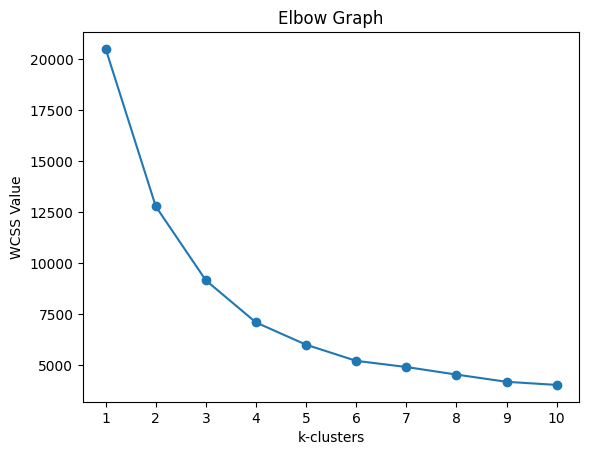

In [8]:
# Elbow Method
WCSS = []

for i in range(1, 11):
    iteration = models.KMeans(n_clusters=i, max_iter=200)
    iteration.fit(X_scaled)
    WCSS.append(iteration.WCSS(X_scaled))

x = range(1, len(WCSS) + 1)

plt.title('Elbow Graph')
plt.xlabel('k-clusters')
plt.ylabel('WCSS Value')
plt.xticks(x)
plt.plot(x, WCSS, marker='o')
plt.show()

### 6. Final Model Instantiation and Algorithmic Execution

With the hyperparameter locked at $K=3$ via our elbow analysis, we initialize and execute our clustering model.

#### Mathematical Explanation: The $K$-Means Optimization Loop

Our custom $K$-Means implementation operates as a non-parametric, iterative optimization algorithm designed to partition $n$ observations into $K$ distinct clusters. Each high school is assigned to the cluster with the nearest mean, which serves as a prototype for that cluster.

The objective function seeks to minimize the total intra-cluster variance, mathematically defined as the global Within-Cluster Sum of Squares (WCSS):

$$J = \sum_{k=1}^{K} \sum_{i \in S_k} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2$$

Where:
* $K = 3$ is the target number of clusters.
* $S_k$ represents the set of data points assigned to cluster $k$.
* $\mathbf{x}_i$ is the multidimensional standardized vector representing high school $i$.
* $\boldsymbol{\mu}_k$ is the centroid vector of cluster $k$, representing the mean profile of all features within that cluster.
* $\| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2$ represents the squared Euclidean distance between the observation vector and its assigned cluster prototype.

The algorithm minimizes this objective function using a two-step iterative optimization loop (Lloyd's Algorithm):

1. **The Assignment Step:** Hold the cluster centroids $\boldsymbol{\mu}_k$ fixed. Assign each high school vector $\mathbf{x}_i$ to its closest centroid based on the minimum squared Euclidean distance:
   
   $$S_k^{(t)} = \left\{ \mathbf{x}_i : \| \mathbf{x}_i - \boldsymbol{\mu}_k^{(t)} \|^2 \le \| \mathbf{x}_i - \boldsymbol{\mu}_j^{(t)} \|^2 \ \forall j, 1 \le j \le K \right\}$$

2. **The Maximization/Update Step:** Hold the newly established cluster boundaries fixed. Calculate the new location of each centroid $\boldsymbol{\mu}_k$ by computing the component-wise mean of all vector coordinates assigned to that group:
   
   $$\boldsymbol{\mu}_k^{(t+1)} = \frac{1}{|S_k^{(t)}|} \sum_{\mathbf{x}_i \in S_k^{(t)}} \mathbf{x}_i$$

This process alternates between assignment and update states until convergence, which occurs when assignments no longer shift or when the system reaches its safety threshold of `max_iter=200`.

#### Integrating Behavioral Semantics into the Dataset

Once the optimization loop achieves mathematical stability, the final state vector of cluster assignments is returned. These integer outputs ($0$, $1$, or $2$) represent the specific behavioral category assigned to each high school. 

By executing `df['Cluster'] = kmeans.fit(X_scaled)`, we map these raw mathematical category assignments back to our labeled database. This connects our complex, multi-dimensional numerical models directly to real-world metadata, such as school names and administrative locations. The resulting augmented matrix provides a clear foundation for our downstream demographic analysis and policy reporting.

In [9]:
kmeans = models.KMeans(n_clusters=3, max_iter=200)
df['Cluster'] = kmeans.fit(X_scaled)

df.head()

,School,City,County/State/Country,App_All,App_Female,App_Male,App_Other,App_Unknown,Adm_All,Adm_Female,...,Yield_All,Acceptance_Male,Yield_Male,Acceptance_Other,Yield_Other,Acceptance_Unknown,Yield_Unknown,Acceptance_Female,Yield_Female,Cluster
1120,WASHINGTON HIGH SCHOOL,Fremont,Alameda,139.0,67.0,67.0,0.0,0.0,14.0,5.0,...,0.428571,0.134328,0.333333,0.0,0.0,0.0,0.0,0.074627,0.6,2
546,MADISON PARK ACADEMY,Oakland,Alameda,14.0,7.0,6.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,1
314,SAN LORENZO HIGH SCHOOL,San Lorenzo,Alameda,21.0,15.0,6.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,1
1151,OAKLAND MILITARY INST COL PREP,Oakland,Alameda,14.0,9.0,5.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,1
731,ALBANY HIGH SCHOOL,Albany,Alameda,154.0,68.0,79.0,0.0,0.0,12.0,5.0,...,0.500000,0.088608,0.428571,0.0,0.0,0.0,0.0,0.073529,0.6,2


### 7. Dimensionality Reduction via Singular Value Decomposition (SVD)

To visualize our 25-dimensional standardized feature matrix ($X_{\text{scaled}}$) on a 2D plane, we apply Singular Value Decomposition (SVD). This matrix factorization captures the axes of maximum variance and projects our high-dimensional data into a low-dimensional subspace without losing structural information.

#### Mathematical Formulation

SVD factorizes our normalized $m \times n$ feature matrix $X_{\text{scaled}}$ (where $m=1206$ high schools and $n=25$ features) into three constituent matrices:

$$X_{\text{scaled}} = U \Sigma V^T$$

Where:
* $U$ is an $m \times n$ ($1206 \times 25$) orthogonal matrix whose columns are the left-singular vectors of $X_{\text{scaled}}$ (the eigenvectors of $X_{\text{scaled}}X_{\text{scaled}}^T$).
* $\Sigma$ is an $n \times n$ diagonal matrix containing the singular values $s_j$ ordered by magnitude: $s_1 \ge s_2 \ge \dots \ge s_n \ge 0$. These values represent the square root of the eigenvalues and quantify the variance captured by each singular vector.
* $V^T$ is an $n \times n$ ($25 \times 25$) orthogonal matrix whose rows are the right-singular vectors of $X_{\text{scaled}}$ (the eigenvectors of $X_{\text{scaled}}^TX_{\text{scaled}}$).

#### Low-Rank Geometric Projection

To reduce dimensions from $\mathbb{R}^{25}$ to $\mathbb{R}^{2}$, we construct a rank-2 approximation by truncating the matrices to the top two singular dimensions:

$$X_{\text{reduced}} = U_{new} \Sigma_{new}$$

Where $U_{new} \in \mathbb{R}^{1206 \times 2}$ represents the first two columns of $U$, and $\Sigma_{new} \in \mathbb{R}^{2 \times 2}$ is the diagonal matrix of the two largest singular values ($s_1, s_2$). This element-wise scaling ($U_{new} \cdot s_{new}$) projects each high school vector into the optimal 2D principal coordinate space, maximizing structural variance preservation for downstream plotting.

In [10]:
U, s, Vt = np.linalg.svd(X_scaled, full_matrices=False)

U_new = U[:, :2]
s_new = s[:2]

X_reduced =  U_new * s_new

X_scaled.shape, U.shape, s.shape, Vt.shape, X_reduced.shape

((1206, 25), (1206, 25), (25,), (25, 25), (1206, 2))

### 8. Structural Interpretation and Geometric Clustering Analysis

By projecting the 25-dimensional feature space onto a 2D plane via Singular Value Decomposition (**SVD**), we can visually audit the structural validity of our $K$-Means boundaries. The geometric distribution of the data points completely mirrors the underlying behavioral patterns of the high school cohorts interacting with UCLA admissions.

#### Geometric Inferences from the SVD Subspace
Looking at the scatter plot, the data follows a continuous behavioral trajectory that spans from highly isolated, hyper-specific outliers to dense, high-volume applicant pools:

* **Cluster 0 (Dark Purple - Left Outliers):** This cluster occupies a highly sparse, high-variance region on the far left of the principal axis (spanning from $-18$ to $-7.5$). Geometrically, these points represent extreme behavioral outliers. They are completely separated from the main body of the dataset, indicating a highly distinct institutional profile that operates independently of typical applicant trends.
* **Cluster 2 (Yellow - Center Distribution):** This cluster forms a sprawling, transitional bridge spanning the center-right spectrum ($-7.5$ to $0$). It represents a massive institutional block showing steady, predictable scaling. The wide vertical distribution reflects healthy internal variance across demographic categories.
* **Cluster 1 (Teal - Right Consolidation):** This cluster tightly packs into a dense, restricted coordinate space on the far right ($0$ to $2.5$). Its high geometric density tells us that these high schools behave with extreme uniformity—the algorithm grouped them because they share an almost identical behavioral signature.

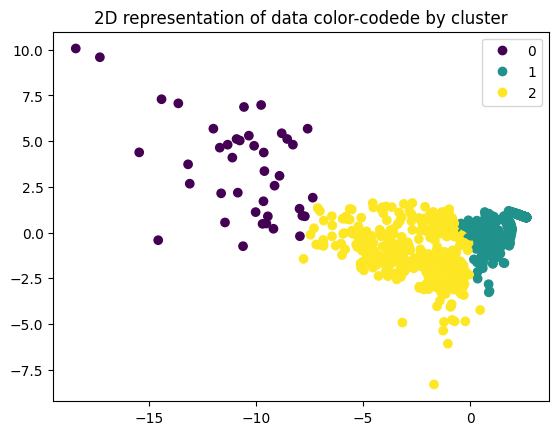

In [11]:
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=kmeans.clusters)
handles, labels = scatter.legend_elements()
plt.legend(handles=handles, labels=labels)
plt.title('2D representation of data color-codede by cluster')
plt.show()


### 9. Cluster Profiling and Cross-Demographic Interpretation

When we match the geometric clusters to our demographic funnel matrix, the data exposes the definitive institutional mechanics behind UCLA's recruitment footprint.

| Cluster | Key Characteristic | Acceptance (All) | Yield (All) | Acceptance (Male) | Yield (Male) | Acceptance (Female) | Yield (Female) |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Cluster 0** | High-Yield Demographic Anchors | $9.45\%$ | $53.01\%$ | $9.69\%$ | $53.57\%$ | $9.30\%$ | $55.22\%$ |
| **Cluster 1** | The Out-of-State "Ghosting Risk" | $4.65\%$ | $9.34\%$ | $1.06\%$ | **$0.00\%$** | $2.80\%$ | **$0.00\%$** |
| **Cluster 2** | Hyper-Elite Feeder Funnels | $11.16\%$ | $68.23\%$ | $7.41\%$ | $31.90\%$ | $12.24\%$ | $57.95\%$ |

#### Cluster 0: The Balanced Demographic Anchors
* **The Data:** Holds a steady $9.45\%$ acceptance rate coupled with a powerful **$53.01\%$ global yield**.
* **Behavioral Analysis:** This segment represents UCLA’s high-performing, high-reliability strongholds. The internal demographics are incredibly well-balanced: males ($53.57\%$) and females ($55.22\%$) enroll at nearly identical, highly efficient rates. When UCLA extends an offer to these schools, more than half of the applicants accept, representing an incredibly stable, foundational revenue and enrollment stream.

#### Cluster 1: The Out-of-State "Ghosting Risk"
* **The Data:** A highly restrictive $4.65\%$ global acceptance rate yielding a dismal **$9.34\%$ overall enrollment**. Crucially, the gender breakdown shows an absolute **$0.00\%$ yield for both identified males and females**.
* **Behavioral Analysis:** This corresponds to the dense, tightly packed teal cluster on our plot. These are elite, hyper-competitive non-California schools where students use a Tier-1 public ivy strictly as a fallback. While a tiny slice of applicants get accepted, the yield completely collapses to zero across major gender cohorts (the small remaining global yield sits in unclassified demographic rows). Students from these schools are overwhelmingly choosing private Ivy League or elite local options over UCLA.

#### Cluster 2: The Hyper-Elite Feeder Funnels
* **The Data:** Boasts the highest overall acceptance rate at $11.16\%$ and an extraordinary global yield of **$68.23\%$**. 
* **Behavioral Analysis:** This is UCLA’s premium, ultra-elite recruitment pipeline (the expansive yellow cluster). However, the demographic breakdown reveals a stark gender disparity: while the female yield is remarkably dominant at $57.95\%$ (paired with a high $12.24\%$ acceptance rate), the male yield takes a massive hit, dropping to $31.90\%$. 

---

### 10. Data-Validated Enrollment Strategy for UCLA

By pairing our SVD coordinate space with the demographic matrix, we can transition from raw data science to a definitive capital-allocation blueprint for UCLA's enrollment management:

1. **Defund Cluster 1 Travel Budgets:** The model proves that sending admissions officers to physical college fairs at Cluster 1 schools yields zero systemic return. UCLA should freeze physical outreach at these schools and transition them to automated digital-marketing funnels.
2. **Reallocate Capital to Cluster 0:** Because Cluster 0 represents highly efficient, balanced conversion channels ($53\%+$ yield across both genders), marketing capital saved from Cluster 1 should be reinvested here to protect and scale these stable pipelines.
3. **Correct the Gender Disparity in Cluster 2:** While Cluster 2 is an incredibly lucrative feeder funnel, its male enrollment path is highly volatile ($31.90\%$ yield vs. $57.95\%$ female yield). UCLA should audit its recruitment materials for these specific schools, deploying targeted outreach to reverse the male conversion drain.

In [12]:

rate_cols = df.columns[18:-1]
cluster_summary = df.groupby('Cluster')[rate_cols].mean() * 100
cluster_summary.columns = [col.replace('_', ' ') for col in cluster_summary.columns]
cluster_summary.round(2).style.background_gradient(cmap='YlGnBu', axis=0).format("{:.2f}%")


,Acceptance All,Yield All,Acceptance Male,Yield Male,Acceptance Other,Yield Other,Acceptance Unknown,Yield Unknown,Acceptance Female,Yield Female
Cluster,,,,,,,,,,
0,9.45%,53.01%,9.69%,53.57%,0.00%,0.00%,0.00%,0.00%,9.30%,55.22%
1,4.65%,9.34%,1.06%,0.00%,0.00%,0.00%,0.00%,0.00%,2.80%,0.00%
2,11.16%,68.23%,7.41%,31.90%,0.00%,0.00%,0.00%,0.00%,12.24%,57.95%


## **Non-Cali Dataset**

In [13]:
df2 = pd.read_csv('../data/GENDER_NONCALI_HS.csv', delimiter='\t', encoding='utf-16')

df2.head()

,Calculation1,School,City,County/State/Country,Count,All,Female,Male,Other,Unknown
0,327 COMPREHENSIVE MODEL SCHOOL331102,327 COMPREHENSIVE MODEL SCHOOL,Bronx,NY,App,NaN,NaN,NaN,NaN,NaN
1,327 COMPREHENSIVE MODEL SCHOOL331102,327 COMPREHENSIVE MODEL SCHOOL,Bronx,NY,Adm,NaN,NaN,NaN,NaN,NaN
2,327 COMPREHENSIVE MODEL SCHOOL331102,327 COMPREHENSIVE MODEL SCHOOL,Bronx,NY,Enr,NaN,NaN,NaN,NaN,NaN
3,A & M CONSOLIDATED HIGH SCHOOL441400,A & M CONSOLIDATED HIGH SCHOOL,College Station,TX,App,7.0,NaN,NaN,NaN,NaN
4,A & M CONSOLIDATED HIGH SCHOOL441400,A & M CONSOLIDATED HIGH SCHOOL,College Station,TX,Adm,NaN,NaN,NaN,NaN,NaN


In [14]:
df2 = dp.clean_data(df2)
df2 = dp.create_parseable_df(df2)
df2 = dp.compute_funnels(df2)

df2.head()

,School,City,County/State/Country,App_All,App_Female,App_Male,App_Other,App_Unknown,Adm_All,Adm_Female,...,Acceptance_All,Yield_All,Acceptance_Male,Yield_Male,Acceptance_Other,Yield_Other,Acceptance_Unknown,Yield_Unknown,Acceptance_Female,Yield_Female
1301,SOUTH HIGH SCHOOL,Anchorage,AK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
965,WEST HIGH SCHOOL,Anchorage,AK,16.0,8.0,6.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536,BARTLETT HIGH SCHOOL,Anchorage,AK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
547,HOOVER HIGH SCHOOL,Hoover,AL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
450,INDIAN SPRINGS SCHOOL,Pelham,AL,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
X2 = df2[df2.columns[3:]].to_numpy()
X2, X2.shape

(array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [16.,  8.,  6., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 7.,  0.,  5., ...,  0.,  0.,  0.],
        [ 5.,  0.,  5., ...,  0.,  0.,  0.],
        [ 9.,  5.,  0., ...,  0.,  0.,  0.]]),
 (1496, 25))

In [16]:
standard_scaler2 = models.StandardScaler()
X_scaled2 = standard_scaler2.fit_transform(X2)
X_scaled2.shape, X_scaled2

((1496, 25),
 array([[-0.87096438, -0.68499681, -0.6241473 , ...,  0.        ,
         -0.25304835, -0.08880341],
        [ 0.08621668,  0.2470225 ,  0.06249888, ...,  0.        ,
         -0.25304835, -0.08880341],
        [-0.87096438, -0.68499681, -0.6241473 , ...,  0.        ,
         -0.25304835, -0.08880341],
        ...,
        [-0.45219767, -0.68499681, -0.05194215, ...,  0.        ,
         -0.25304835, -0.08880341],
        [-0.5718453 , -0.68499681, -0.05194215, ...,  0.        ,
         -0.25304835, -0.08880341],
        [-0.33255004, -0.10248474, -0.6241473 , ...,  0.        ,
         -0.25304835, -0.08880341]]))

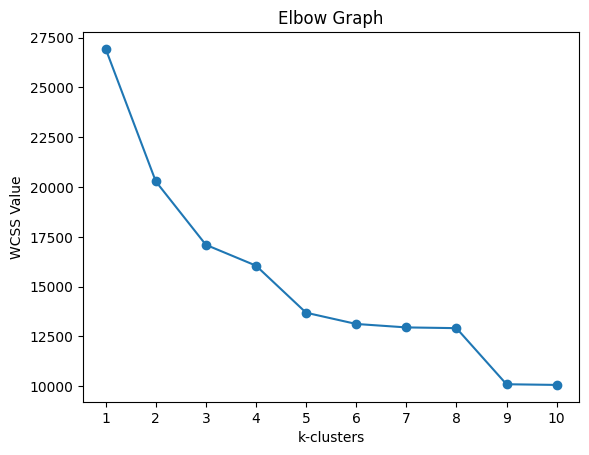

In [19]:
# Elbow Method
WCSS = []

for i in range(1, 11):
    iteration = models.KMeans(n_clusters=i, max_iter=2000)
    iteration.fit(X_scaled2)
    WCSS.append(iteration.WCSS(X_scaled2))

x = range(1, len(WCSS) + 1)

plt.title('Elbow Graph')
plt.xlabel('k-clusters')
plt.ylabel('WCSS Value')
plt.xticks(x)
plt.plot(x, WCSS, marker='o')
plt.show()

In [28]:
kmeans2 = models.KMeans(n_clusters=3, max_iter=500)
df2['Cluster'] = kmeans2.fit(X_scaled2)

df2.head()

,School,City,County/State/Country,App_All,App_Female,App_Male,App_Other,App_Unknown,Adm_All,Adm_Female,...,Yield_All,Acceptance_Male,Yield_Male,Acceptance_Other,Yield_Other,Acceptance_Unknown,Yield_Unknown,Acceptance_Female,Yield_Female,Cluster
1301,SOUTH HIGH SCHOOL,Anchorage,AK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
965,WEST HIGH SCHOOL,Anchorage,AK,16.0,8.0,6.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
536,BARTLETT HIGH SCHOOL,Anchorage,AK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
547,HOOVER HIGH SCHOOL,Hoover,AL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
450,INDIAN SPRINGS SCHOOL,Pelham,AL,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [29]:
U, s, Vt = np.linalg.svd(X_scaled2, full_matrices=False)

U_new = U[:, :2]
s_new = s[:2]

X_reduced2 =  U_new * s_new

X_scaled2.shape, U.shape, s.shape, Vt.shape, X_reduced2.shape

((1496, 25), (1496, 25), (25,), (25, 25), (1496, 2))

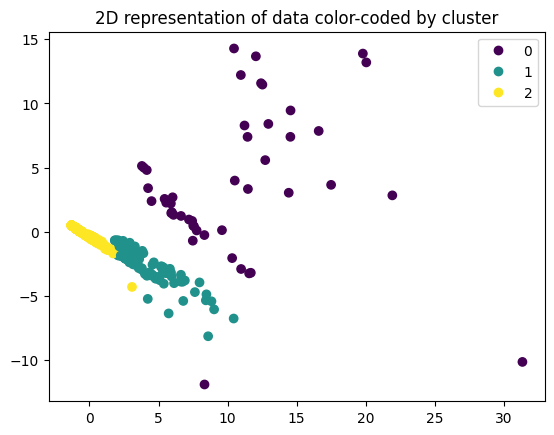

In [30]:
scatter = plt.scatter(X_reduced2[:, 0], X_reduced2[:, 1], c=kmeans2.clusters)
handles, labels = scatter.legend_elements()
plt.legend(handles=handles, labels=labels)
plt.title('2D representation of data color-coded by cluster')
plt.show()

In [31]:
rate_cols = df2.columns[18:-1]
cluster_summary = df2.groupby('Cluster')[rate_cols].mean() * 100
cluster_summary.columns = [col.replace('_', ' ') for col in cluster_summary.columns]
cluster_summary.round(2).style.background_gradient(cmap='YlGnBu', axis=0).format("{:.2f}%")

,Acceptance All,Yield All,Acceptance Male,Yield Male,Acceptance Other,Yield Other,Acceptance Unknown,Yield Unknown,Acceptance Female,Yield Female
Cluster,,,,,,,,,,
0,17.84%,54.94%,12.29%,11.35%,0.00%,0.00%,0.00%,0.00%,13.27%,19.88%
1,17.14%,0.00%,10.79%,0.00%,0.00%,0.00%,0.00%,0.00%,14.86%,0.00%
2,2.26%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
